### Optimization notes
- This copy replaces SMOTE with cost-sensitive learning.
- CSV numeric columns are downcast during load to reduce RAM.
- Feature selection uses at most 200,000 sampled rows.
- Cross-validation is run with `n_jobs=1` at the outer level to avoid >8 GB RAM spikes.
- A deprecated duplicate model cell was disabled so it cannot accidentally re-run stale SMOTE code.


In [20]:
%pip install optuna_integration

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.




[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os
import time
import glob

# Sklearn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

# Imbalanced-learn

# LightGBM + Optuna+XGBoost
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 120

print('All libraries imported successfully!')
import sklearn, imblearn
print(f'sklearn={sklearn.__version__} | imbalanced-learn={imblearn.__version__}')

All libraries imported successfully!
sklearn=1.6.1 | imbalanced-learn=0.13.0


In [21]:
DATA_FOLDER = r"C:\Users\STUTI\Documents\MachineLearningCSV\MachineLearningCVE" 
# ============================================================

# All 8 expected files 
EXPECTED_FILES = [
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
]

print('Checking file availability...')
found, missing = [], []
for fname in EXPECTED_FILES:
    fpath = os.path.join(DATA_FOLDER, fname)
    if os.path.exists(fpath):
        size_mb = os.path.getsize(fpath) / (1024 * 1024)
        print(f'  OK   {fname}  ({size_mb:.0f} MB)')
        found.append(fpath)
    else:
        print(f'  MISSING  {fname}')
        missing.append(fname)

if missing:
    print(f'\n  {len(missing)} file(s) missing. Download from:')
    print('   https://www.unb.ca/cic/datasets/ids-2017.html')
    print('   Look for the MachineLearningCVE folder.')
else:
    print(f'\n  All {len(found)} files found.')

Checking file availability...
  OK   Monday-WorkingHours.pcap_ISCX.csv  (169 MB)
  OK   Tuesday-WorkingHours.pcap_ISCX.csv  (129 MB)
  OK   Wednesday-workingHours.pcap_ISCX.csv  (215 MB)
  OK   Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  (50 MB)
  OK   Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  (79 MB)
  OK   Friday-WorkingHours-Morning.pcap_ISCX.csv  (56 MB)
  OK   Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv  (73 MB)
  OK   Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv  (74 MB)

✅  All 8 files found.


In [22]:
# Load and concatenate all files
# RAM note: cast numeric columns to float32/int32 before concatenation to reduce peak memory.

dfs = []
for fpath in found:
    fname = os.path.basename(fpath)
    df_tmp = pd.read_csv(fpath, encoding='utf-8', low_memory=False)
    df_tmp.columns = df_tmp.columns.str.strip()

    num_cols = df_tmp.select_dtypes(include=[np.number]).columns
    float_cols = df_tmp[num_cols].select_dtypes(include=['float64']).columns
    int_cols = df_tmp[num_cols].select_dtypes(include=['int64']).columns

    if len(float_cols) > 0:
        df_tmp[float_cols] = df_tmp[float_cols].astype('float32')
    if len(int_cols) > 0:
        df_tmp[int_cols] = df_tmp[int_cols].astype('int32')

    dfs.append(df_tmp)
    print(f'  Loaded {fname}: {df_tmp.shape[0]:,} rows, {df_tmp.shape[1]} cols')


# If RAM is still tight on your machine, the next step would be a parquet/chunked pipeline.
df = pd.concat(dfs, ignore_index=True)
del dfs

print(f'Combined dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Label distribution (raw):')
print(df['Label'].value_counts().to_string())

  Loaded Monday-WorkingHours.pcap_ISCX.csv: 529,918 rows, 79 cols
  Loaded Tuesday-WorkingHours.pcap_ISCX.csv: 445,909 rows, 79 cols
  Loaded Wednesday-workingHours.pcap_ISCX.csv: 692,703 rows, 79 cols
  Loaded Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: 170,366 rows, 79 cols
  Loaded Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: 288,602 rows, 79 cols
  Loaded Friday-WorkingHours-Morning.pcap_ISCX.csv: 191,033 rows, 79 cols
  Loaded Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: 286,467 rows, 79 cols
  Loaded Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: 225,745 rows, 79 cols
Combined dataset: 2,830,743 rows x 79 columns
Label distribution (raw):
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    57

In [23]:
# Step 1: Replace infinities with NaN
# Why: sklearn and LightGBM cannot handle inf — they produce nan predictions silently
before_shape = df.shape[0]
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f'Rows before NaN drop: {before_shape:,}')

df.dropna(inplace=True)
print(f'Rows after NaN drop : {df.shape[0]:,}  ({before_shape - df.shape[0]:,} removed)')

# Step 3: Normalise label strings
df['Label'] = df['Label'].str.strip().str.replace(r'\s+', ' ', regex=True)

print(f'\nLabel distribution after cleaning:')
label_counts = df['Label'].value_counts()
print(label_counts.to_string())

Rows before NaN drop: 2,830,743
Rows after NaN drop : 2,827,876  (2,867 removed)

Label distribution after cleaning:
Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11


In [24]:
# Step 4: Remove classes with fewer than 50 samples
.
MIN_SAMPLES = 50
valid_labels = label_counts[label_counts >= MIN_SAMPLES].index
removed = label_counts[label_counts < MIN_SAMPLES]

if len(removed) > 0:
    print(f'Removing {len(removed)} class(es) with < {MIN_SAMPLES} samples:')
    for lbl, cnt in removed.items():
        print(f'  {lbl}: {cnt} samples')
    df = df[df['Label'].isin(valid_labels)]
    print(f'Remaining rows: {df.shape[0]:,}')
else:
    print(f'All classes have >= {MIN_SAMPLES} samples. No classes removed.')

# Step 5: Binary label ? BENIGN=0, any attack=1
df['binary_label'] = (df['Label'] != 'BENIGN').astype(int)
print(f'Binary label distribution:')
bin_counts = df['binary_label'].value_counts()
print(f'  BENIGN (0): {bin_counts[0]:,}')
print(f'  ATTACK (1): {bin_counts[1]:,}')
print(f'  Imbalance ratio: {bin_counts[0]/bin_counts[1]:.2f}:1')

Removing 3 class(es) with < 50 samples:
  Infiltration: 36 samples
  Web Attack � Sql Injection: 21 samples
  Heartbleed: 11 samples
Remaining rows: 2,827,808
Binary label distribution:
  BENIGN (0): 2,271,320
  ATTACK (1): 556,488
  Imbalance ratio: 4.08:1


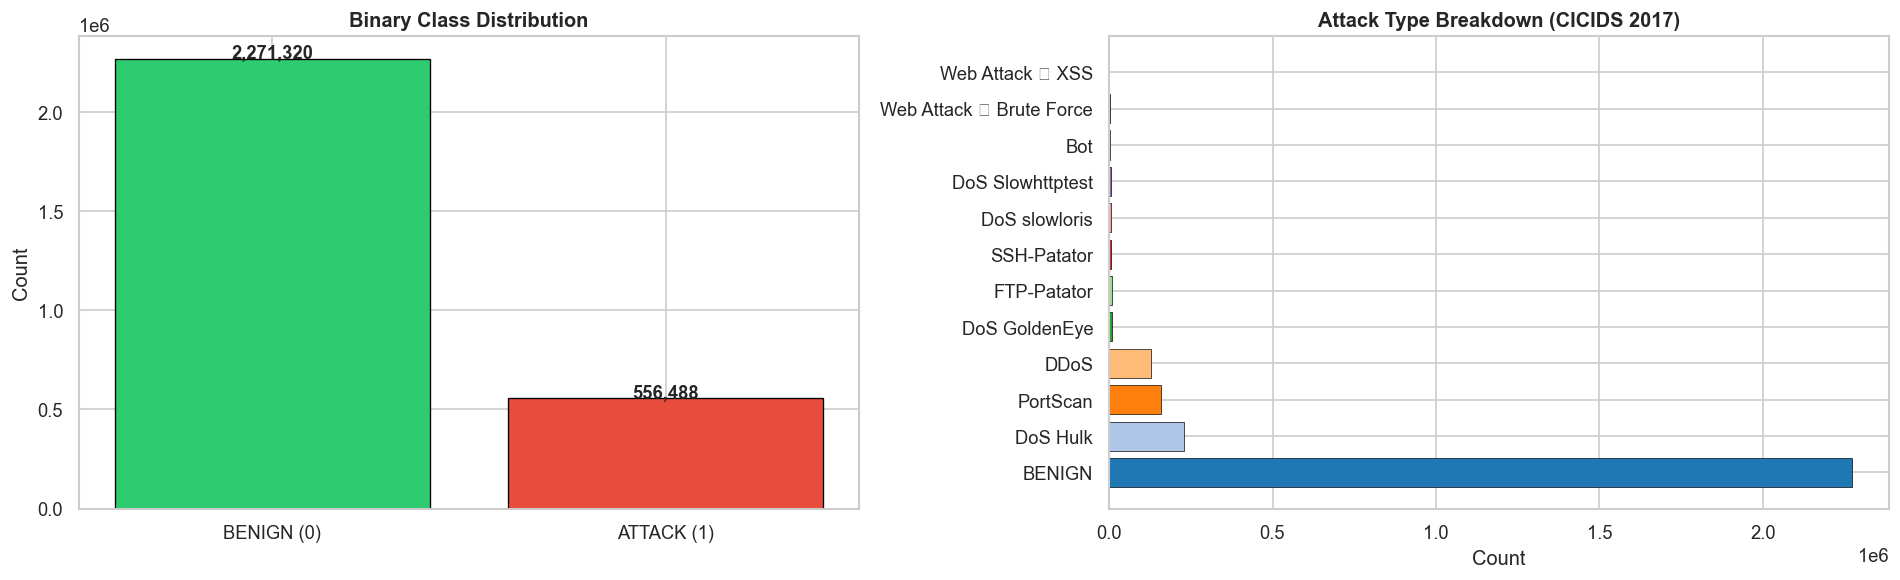

Saved: class_distribution.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Binary distribution
bars = axes[0].bar(['BENIGN (0)', 'ATTACK (1)'],
                   [bin_counts[0], bin_counts[1]],
                   color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, [bin_counts[0], bin_counts[1]]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Binary Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')

# Multi-class breakdown
atk_counts = df['Label'].value_counts()
colors_bar = sns.color_palette('tab20', len(atk_counts))
axes[1].barh(atk_counts.index, atk_counts.values, color=colors_bar,
             edgecolor='black', linewidth=0.4)
axes[1].set_title('Attack Type Breakdown (CICIDS 2017)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: class_distribution.png')

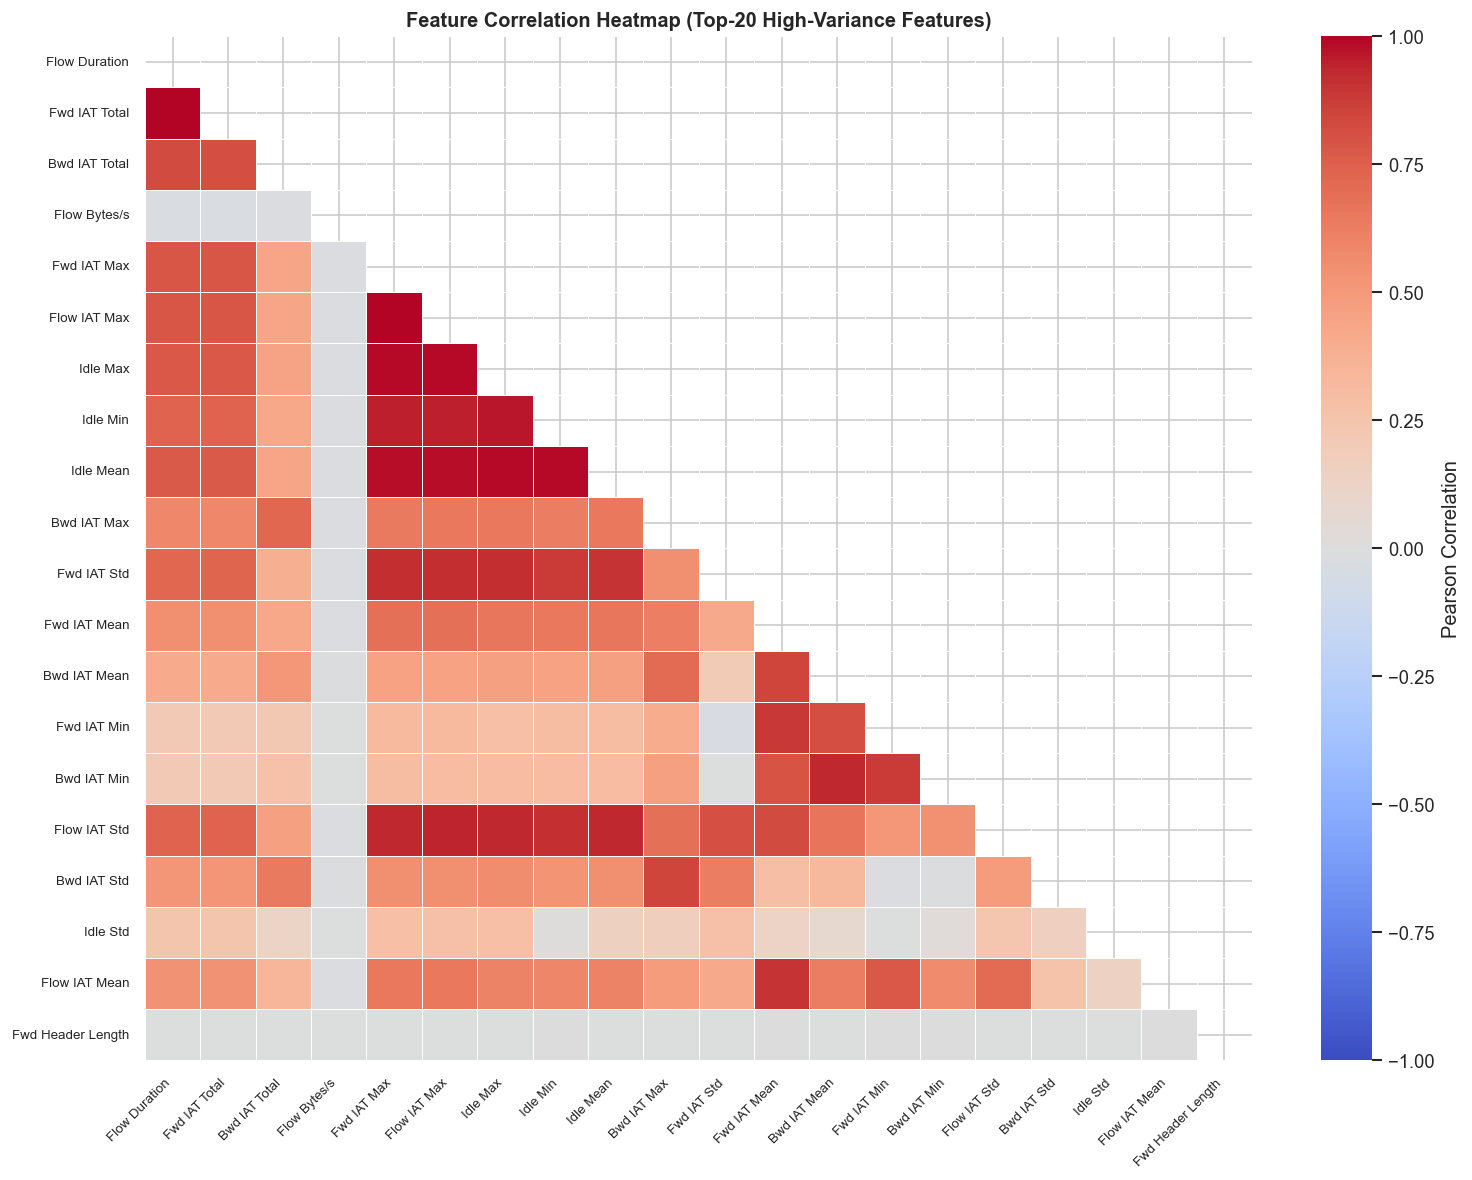

Saved: correlation_heatmap.png


In [26]:
# Correlation heatmap on top-20 highest-variance numeric features
# Why top-20 only: 78-feature heatmap is unreadable; high-variance features

feature_cols_all = [c for c in df.columns if c not in ['Label', 'binary_label']]
numeric_cols = df[feature_cols_all].select_dtypes(include=[np.number]).columns.tolist()
top20 = df[numeric_cols].var().nlargest(20).index.tolist()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones((20, 20), dtype=bool))
sns.heatmap(df[top20].corr(), mask=mask, cmap='coolwarm', center=0,
            linewidths=0.3, annot=False, vmin=-1, vmax=1,
            cbar_kws={'label': 'Pearson Correlation'})
plt.title('Feature Correlation Heatmap (Top-20 High-Variance Features)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: correlation_heatmap.png')

In [27]:
# Select only numeric feature columns (drop Label and binary_label)
feature_cols = df[feature_cols_all].select_dtypes(include=[np.number]).columns.tolist()
X = df[feature_cols].copy()
y = df['binary_label'].copy()

print(f'Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} columns')
print(f'All features are numeric — no label encoding required')

Feature matrix: 2,827,808 rows x 78 columns
All features are numeric — no label encoding required


In [28]:
# Feature Engineering

def add_features(df_in):
    df_out = df_in.copy()
    eps = 1e-9

    # Fwd/Bwd byte ratio — asymmetry indicator for exfiltration
    if 'Total Length of Fwd Packets' in df_out.columns and 'Total Length of Bwd Packets' in df_out.columns:
        df_out['fwd_bwd_bytes_ratio'] = (
            df_out['Total Length of Fwd Packets'] /
            (df_out['Total Length of Bwd Packets'] + eps)
        )
    else:
        df_out['fwd_bwd_bytes_ratio'] = 0.0

    # Packet length asymmetry — large difference = scanning probe pattern
    if 'Max Packet Length' in df_out.columns and 'Min Packet Length' in df_out.columns:
        df_out['pkt_len_asymmetry'] = (
            df_out['Max Packet Length'] - df_out['Min Packet Length']
        ) / (df_out['Max Packet Length'] + eps)
    else:
        df_out['pkt_len_asymmetry'] = 0.0

    # IAT ratio — fwd vs bwd inter-arrival time asymmetry (slow DoS indicator)
    if 'Fwd IAT Mean' in df_out.columns and 'Bwd IAT Mean' in df_out.columns:
        df_out['iat_ratio'] = (
            df_out['Fwd IAT Mean'] / (df_out['Bwd IAT Mean'] + eps)
        )
    else:
        df_out['iat_ratio'] = 0.0

    # Clip extreme engineered values (log-transform alternative considered
    # but clipping is safer for the Streamlit live-traffic inference path)
    for col in ['fwd_bwd_bytes_ratio', 'iat_ratio']:
        if col in df_out.columns:
            df_out[col] = df_out[col].clip(-1e6, 1e6)

    return df_out

X_eng = add_features(X)
eng_feats = ['fwd_bwd_bytes_ratio', 'pkt_len_asymmetry', 'iat_ratio']
print(f'Added {len(eng_feats)} engineered features: {eng_feats}')
print(f'Total features: {X_eng.shape[1]}')

Added 3 engineered features: ['fwd_bwd_bytes_ratio', 'pkt_len_asymmetry', 'iat_ratio']
Total features: 81


In [29]:
# Train/Test split — 80/20, stratified

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_eng, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train_raw.shape[0]:,} rows | Test: {X_test_raw.shape[0]:,} rows')
print(f'Train attack ratio: {y_train.mean():.3f}')
print(f'Test  attack ratio: {y_test.mean():.3f}')

Train: 2,262,246 rows | Test: 565,562 rows
Train attack ratio: 0.197
Test  attack ratio: 0.197


In [30]:
# StandardScaler 
# for GaussianNB and for consistent saved inference artifacts.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

all_features   = X_eng.columns.tolist()
X_train_scaled = pd.DataFrame(X_train_scaled, columns=all_features)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=all_features)

print(f'Scaling complete. Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')

Scaling complete. Train: (2262246, 81) | Test: (565562, 81)


In [31]:

#  Fast feature selection with LightGBM + XGBoost
N_FEATURES = 25
FEATURE_SAMPLE_SIZE = min(200_000, len(X_train_scaled))

if len(X_train_scaled) > FEATURE_SAMPLE_SIZE:
    X_fs, _, y_fs, _ = train_test_split(
        X_train_scaled,
        y_train,
        train_size=FEATURE_SAMPLE_SIZE,
        stratify=y_train,
        random_state=42
    )
else:
    X_fs, y_fs = X_train_scaled.copy(), y_train.copy()

selector_models = {
    "LightGBM": LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=1,
        verbose=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        eval_metric="logloss",
        objective="binary:logistic",
        random_state=42,
        n_jobs=1,
        verbosity=0
    )
}

feature_scores = pd.DataFrame(index=all_features)

for name, model in selector_models.items():
    model.fit(X_fs, y_fs)
    scores = pd.Series(model.feature_importances_, index=all_features, dtype="float64")
    total = scores.sum()
    feature_scores[name] = scores / total if total else scores

feature_scores["mean_importance"] = feature_scores.mean(axis=1)

selected_features = (
    feature_scores["mean_importance"]
    .sort_values(ascending=False)
    .head(N_FEATURES)
    .index
    .tolist()
)

selector_importances = (
    feature_scores.loc[selected_features, "mean_importance"]
    .sort_values(ascending=True)
)

X_train_selected = X_train_scaled[selected_features].copy()
X_test_selected  = X_test_scaled[selected_features].copy()

print(f"Feature selection sample size: {len(X_fs):,}")
print(f"Selected {len(selected_features)} features via LightGBM + XGBoost importance.")
print(selected_features)

Feature selection sample size: 200,000
Selected 25 features via LightGBM + XGBoost importance.
['Avg Bwd Segment Size', 'Average Packet Size', 'Init_Win_bytes_forward', 'Destination Port', 'Bwd Header Length', 'Bwd Packet Length Std', 'Init_Win_bytes_backward', 'Packet Length Variance', 'Flow IAT Min', 'Bwd Packet Length Min', 'Max Packet Length', 'Packet Length Std', 'Fwd IAT Min', 'min_seg_size_forward', 'Total Length of Bwd Packets', 'Fwd Header Length', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packets/s', 'Flow Bytes/s', 'Bwd Packets/s', 'Flow Duration', 'fwd_bwd_bytes_ratio', 'Bwd Packet Length Mean', 'Total Backward Packets']


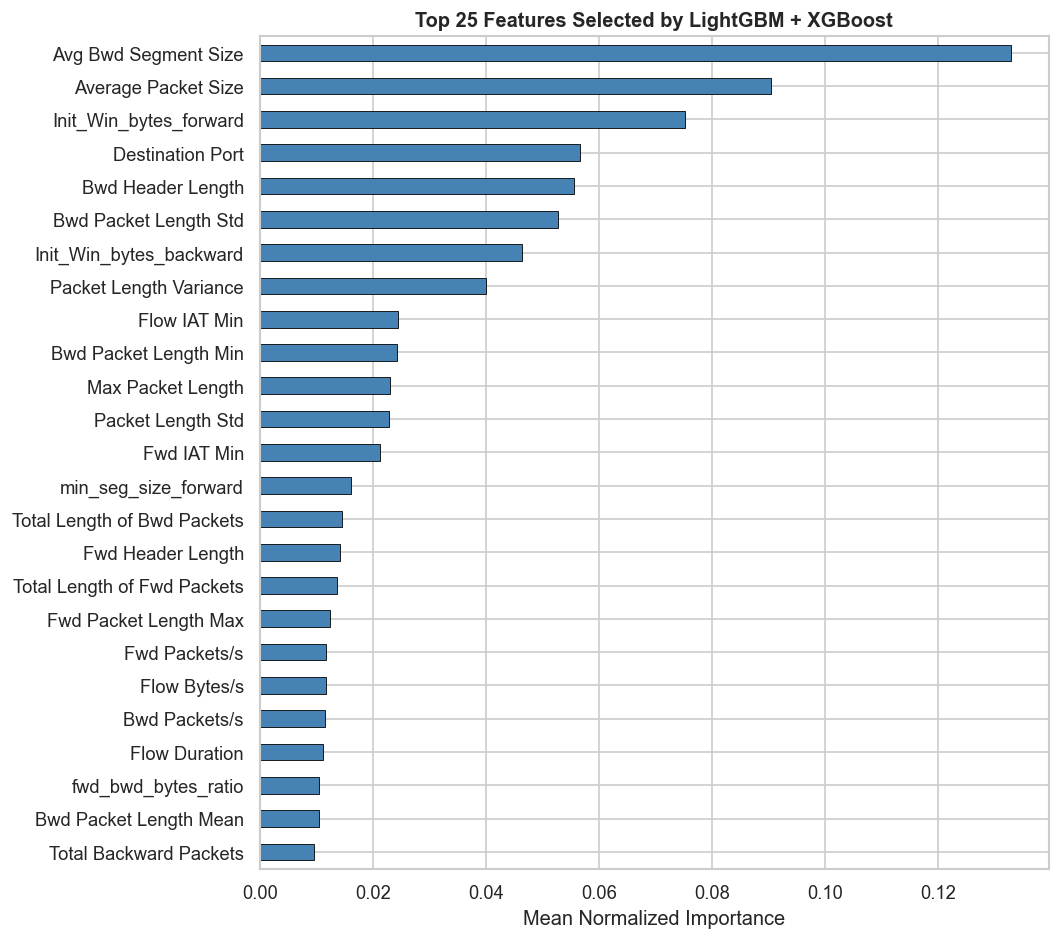

Saved: tree_feature_importance.png
Final training shape: (2262246, 25)


In [32]:

# 9. Plot selected feature importance

plt.figure(figsize=(9, 8))
selector_importances.plot(kind="barh", color="steelblue", edgecolor="black", linewidth=0.5)
plt.title("Top 25 Features Selected by LightGBM + XGBoost", fontsize=12, fontweight="bold")
plt.xlabel("Mean Normalized Importance")
plt.tight_layout()
plt.savefig("tree_feature_importance.png", bbox_inches="tight")
plt.show()

print("Saved: tree_feature_importance.png")
print(f"Final training shape: {X_train_selected.shape}")


In [33]:
# 10. Cost-sensitive learning setup

print("Training class distribution:")
print(pd.Series(y_train).value_counts().to_string())

class_counts = pd.Series(y_train).value_counts()
neg_count = class_counts.get(0, 1)
pos_count = class_counts.get(1, 1)

# Useful for XGBoost binary imbalance handling
scale_pos_weight = neg_count / pos_count

print(f"\nComputed scale_pos_weight: {scale_pos_weight:.4f}")

# No resampling: use the selected feature set directly
X_train_cs = X_train_selected.copy()
y_train_cs = y_train.copy()

print(f"Cost-sensitive training shape: {X_train_cs.shape}")


Training class distribution:
binary_label
0    1817056
1     445190

Computed scale_pos_weight: 4.0815
Cost-sensitive training shape: (2262246, 25)


In [34]:
import optuna
from optuna.integration import LightGBMPruningCallback
import lightgbm as lgb
from lightgbm import LGBMClassifier

from sklearn.metrics import f1_score
import numpy as np

# 1. Define the custom F1 metric for LightGBM's eval_set
def lgb_f1_score(y_true, y_pred):
    y_pred = (y_pred > 0.5).astype(int) # Convert probabilities to binary
    return 'f1', f1_score(y_true, y_pred), True # True means higher is better

def objective(trial):
    params = {
        "n_estimators": 1000, 
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "num_leaves": trial.suggest_int("num_leaves", 20, 160),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 80),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs": 1,
        "verbose": -1
    }

    X_t, X_v, y_t, y_v = train_test_split(X_train_cs, y_train_cs, test_size=0.2, stratify=y_train_cs)
    
    model = lgb.LGBMClassifier(**params)
    
    model.fit(
        X_t, y_t,
        eval_set=[(X_v, y_v)],
        # Use feval for the custom metric instead of eval_metric string
        eval_metric=lgb_f1_score, 
        callbacks=[
            # This will now find "f1" in the results list
            optuna.integration.LightGBMPruningCallback(trial, "f1"),
            lgb.early_stopping(stopping_rounds=25)
        ]
    )
    
    preds = model.predict(X_v)
    return f1_score(y_v, preds)

# Use TPESampler with multivariate=True to find relationships between params faster
study = optuna.create_study(
    direction="maximize", 
    sampler=optuna.samplers.TPESampler(multivariate=True),
    pruner=optuna.pruners.MedianPruner()
)
N_TRIALS=25
study.optimize(objective, n_trials=N_TRIALS)

Training until validation scores don't improve for 25 rounds
Early stopping, best iteration is:
[166]	valid_0's binary_logloss: 0.00322426	valid_0's f1: 0.997809
Training until validation scores don't improve for 25 rounds
Early stopping, best iteration is:
[314]	valid_0's binary_logloss: 0.00317193	valid_0's f1: 0.997792
Training until validation scores don't improve for 25 rounds
Early stopping, best iteration is:
[376]	valid_0's binary_logloss: 0.00357713	valid_0's f1: 0.997579
Training until validation scores don't improve for 25 rounds
Early stopping, best iteration is:
[584]	valid_0's binary_logloss: 0.00357696	valid_0's f1: 0.997535
Training until validation scores don't improve for 25 rounds
Early stopping, best iteration is:
[123]	valid_0's binary_logloss: 0.00424115	valid_0's f1: 0.997261
Training until validation scores don't improve for 25 rounds
Training until validation scores don't improve for 25 rounds
Early stopping, best iteration is:
[91]	valid_0's binary_logloss: 0.

In [35]:
# Deprecated duplicate cell removed in optimized notebook..
print('Skipped deprecated duplicate model-comparison cell.')

Skipped deprecated duplicate model-comparison cell.


In [37]:
from sklearn.model_selection import train_test_split

# With 2M+ rows, a 20% split is extremely representative.
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_cs, y_train_cs, test_size=0.2, stratify=y_train_cs, random_state=42
)

models = {
    "LightGBM (tuned)": LGBMClassifier(**best_lgbm_params),
    "Random Forest (Fast)": RandomForestClassifier(
        n_estimators=100, # Reduced from 300
        max_samples=0.1,  # Train each tree on only 10% of data (huge speedup)
        class_weight="balanced",
        max_depth=15, 
        n_jobs=-1,        # Use all cores for RF
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        tree_method="hist", 
        device="cuda",    # Change to "cpu" if you don't have a GPU
        n_estimators=150, # Reduced for comparison speed
        learning_rate=0.1,
        max_depth=6,
        n_jobs=-1,
        random_state=42
    ),
    "Naive Bayes": GaussianNB()
}

results = {}
trained_models = {}
y_proba_dict = {}

print(f'{"Model":<26} {"F1 Score":>12} {"Training Time":>12}')
print("-" * 55)

import time

for name, model in models.items():
    start_time = time.time()
    
    # Train once
    model.fit(X_train_sub, y_train_sub)
    elapsed = time.time() - start_time
    
    # Predict on validation set
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]
    
    f1 = f1_score(y_val, y_pred, zero_division=0)
    
    # Store results
    trained_models[name] = model
    y_proba_dict[name] = y_prob
    results[name] = {
        'Accuracy': accuracy_score(y_val, y_pred),
        'F1': f1,
        'Precision': precision_score(y_val, y_pred, zero_division=0),
        'Recall': recall_score(y_val, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_val, y_prob),
        'CM': confusion_matrix(y_val, y_pred)
    }
    
    print(f'{name:<26} {f1:>12.4f} {elapsed:>11.2f}s')

print('\nAll models evaluated using hold-out validation for speed.')

Model                          F1 Score Training Time
-------------------------------------------------------
LightGBM (tuned)                 0.9967       58.39s
Random Forest (Fast)             0.9969       29.11s
XGBoost                          0.9979       17.27s
Naive Bayes                      0.3983        1.43s

All models evaluated using hold-out validation for speed.


In [40]:
print('Threshold Tuning Results')
print(f'{"Model":<26} {"Default F1":>11} {"Best Thresh":>12} {"Tuned F1":>10} {"Tuned Recall":>13}')
print('-' * 76)

tuned_results   = {}
best_thresholds = {}

for name in models:
    y_prob     = y_proba_dict[name]
    default_f1 = results[name]['F1']

    thresholds = np.linspace(0.1, 0.9, 81)
    best_t, best_f1_t = 0.5, 0.0
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        f1_t     = f1_score(y_val, y_pred_t, zero_division=0)
        if f1_t > best_f1_t:
            best_f1_t, best_t = f1_t, t

    y_pred_best = (y_prob >= best_t).astype(int)
    tuned_rec   = recall_score(y_val, y_pred_best)
    tuned_prec  = precision_score(y_val, y_pred_best, zero_division=0)
    tuned_acc   = accuracy_score(y_val, y_pred_best)

    best_thresholds[name] = best_t
    tuned_results[name]   = {
        'Accuracy':  tuned_acc,
        'F1':        best_f1_t,
        'Precision': tuned_prec,
        'Recall':    tuned_rec,
        'AUC':       results[name]['AUC'],
        'Threshold': best_t,
        'CM':        confusion_matrix(y_val, y_pred_best)
    }

    gain  = best_f1_t - default_f1
    arrow = '↑' if gain > 0.0001 else '–'
    print(f'{name:<26} {default_f1:>11.4f} {best_t:>12.2f} {best_f1_t:>10.4f} {tuned_rec:>13.4f}   {arrow} {abs(gain):.4f}')

print('\nThreshold tuning complete.')

Threshold Tuning Results
Model                       Default F1  Best Thresh   Tuned F1  Tuned Recall
----------------------------------------------------------------------------
LightGBM (tuned)                0.9967         0.77     0.9973        0.9983   ↑ 0.0006
Random Forest (Fast)            0.9969         0.41     0.9969        0.9994   – 0.0001
XGBoost                         0.9979         0.54     0.9980        0.9986   – 0.0000
Naive Bayes                     0.3983         0.90     0.4028        0.9848   ↑ 0.0045

Threshold tuning complete.


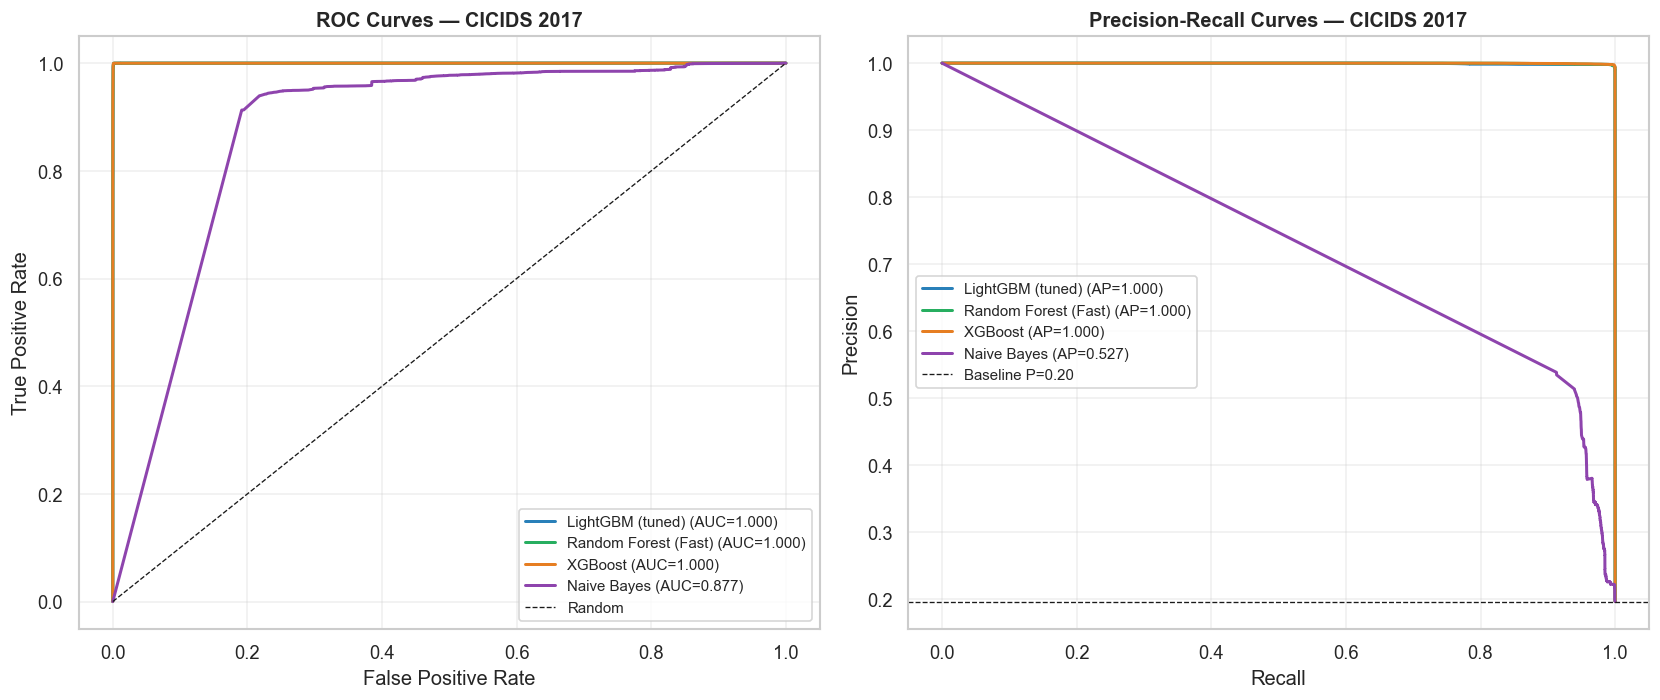

Saved: roc_pr_curves.png


In [44]:
colors = ['#2980b9', '#27ae60', '#e67e22', '#8e44ad']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for (name, y_prob), color in zip(y_proba_dict.items(), colors):
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc_val     = roc_auc_score(y_val, y_prob)
    axes[0].plot(fpr, tpr, color=color, linewidth=1.8,
                 label=f'{name} (AUC={auc_val:.3f})')

    prec_c, rec_c, _ = precision_recall_curve(y_val, y_prob)
    ap_val = average_precision_score(y_val, y_prob)
    axes[1].plot(rec_c, prec_c, color=color, linewidth=1.8,
                 label=f'{name} (AP={ap_val:.3f})')

axes[0].plot([0,1],[0,1],'k--',linewidth=0.8,label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — CICIDS 2017', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

baseline = y_test.mean()
axes[1].axhline(baseline, color='k', linestyle='--', linewidth=0.8,
                label=f'Baseline P={baseline:.2f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — CICIDS 2017', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', bbox_inches='tight')
plt.show()
print('Saved: roc_pr_curves.png')

In [46]:
for name in models:
    y_prob    = y_proba_dict[name]
    threshold = best_thresholds[name]
    y_pred_t  = (y_prob >= threshold).astype(int)
    print(f'{'='*55}')
    print(f'  {name}  (threshold = {threshold:.2f})')
    print(f'{'='*55}')
    print(classification_report(y_val, y_pred_t, target_names=['BENIGN', 'ATTACK']))
    print()

  LightGBM (tuned)  (threshold = 0.77)
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    363412
      ATTACK       1.00      1.00      1.00     89038

    accuracy                           1.00    452450
   macro avg       1.00      1.00      1.00    452450
weighted avg       1.00      1.00      1.00    452450


  Random Forest (Fast)  (threshold = 0.41)
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    363412
      ATTACK       0.99      1.00      1.00     89038

    accuracy                           1.00    452450
   macro avg       1.00      1.00      1.00    452450
weighted avg       1.00      1.00      1.00    452450


  XGBoost  (threshold = 0.54)
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    363412
      ATTACK       1.00      1.00      1.00     89038

    accuracy                           1.00    452450
   macro avg  

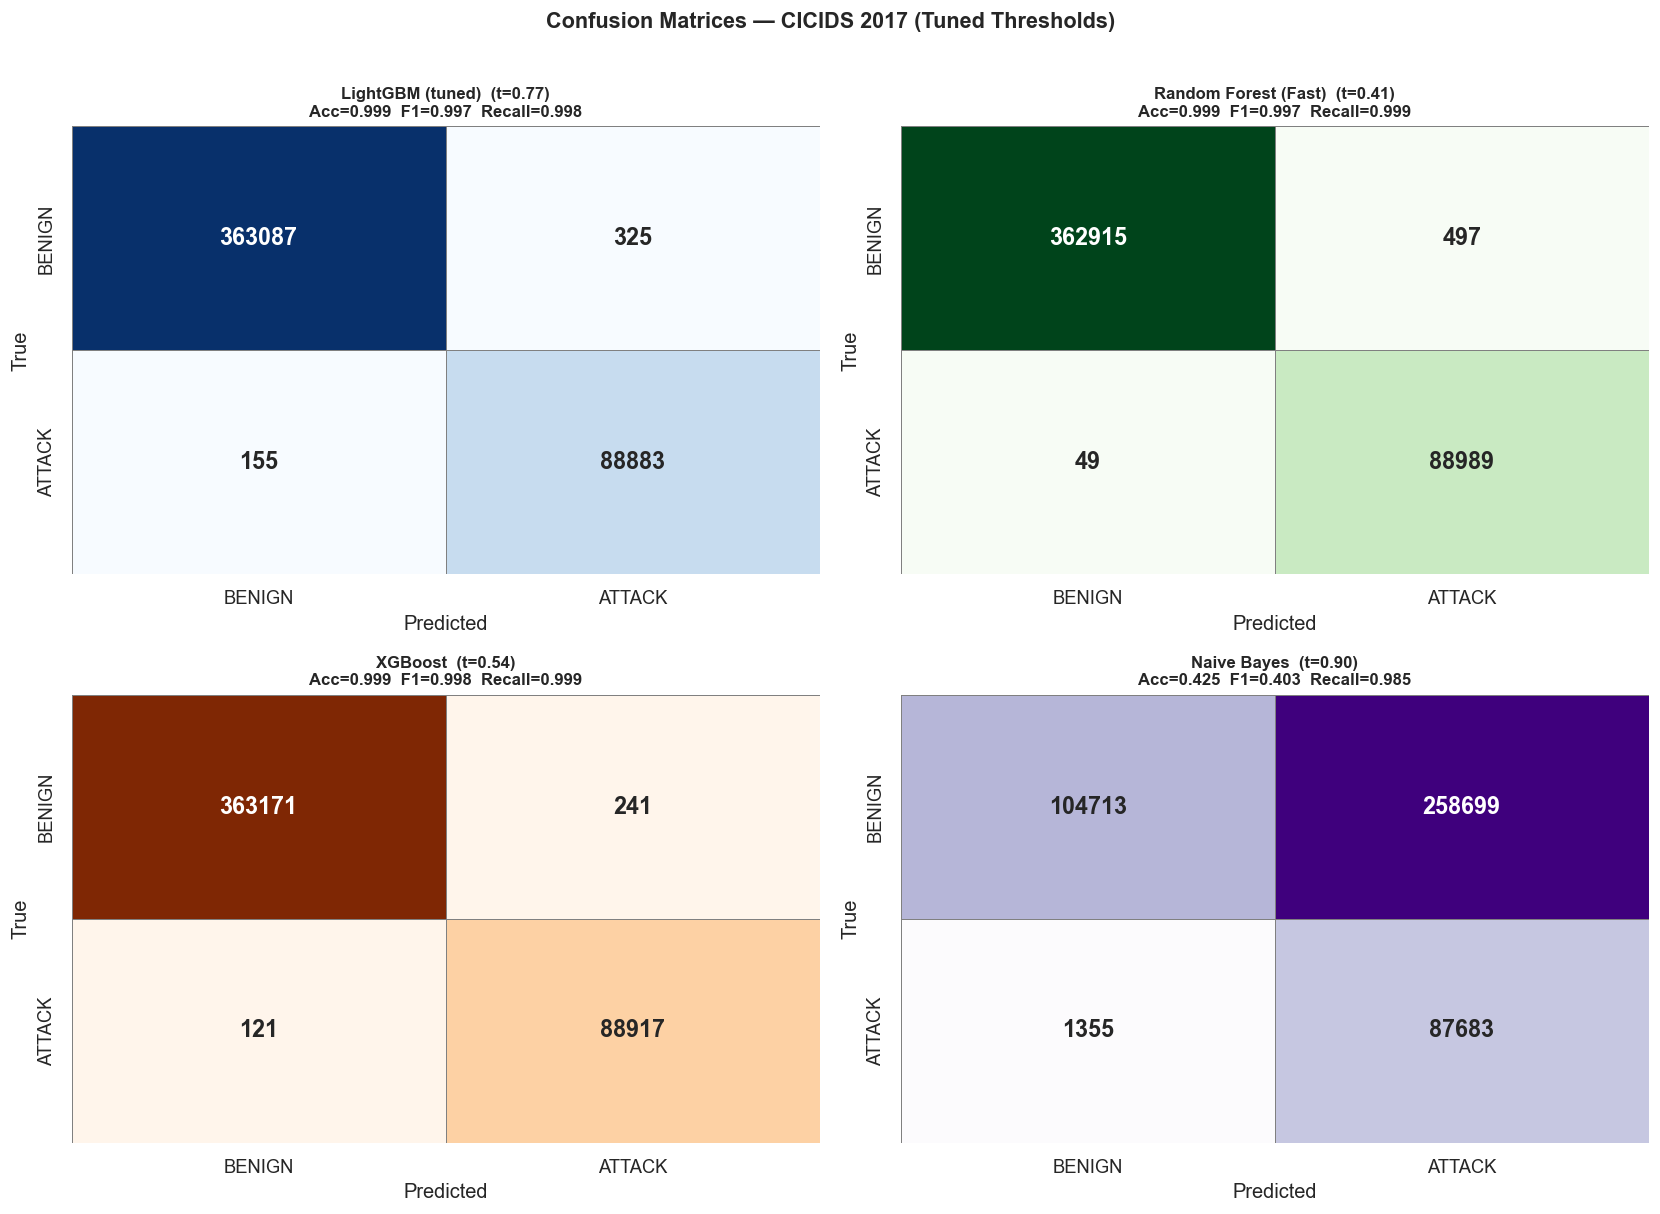

Saved: confusion_matrices.png


In [47]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes      = axes.flatten()
class_names = ['BENIGN', 'ATTACK']
cmap_list   = ['Blues', 'Greens', 'Oranges', 'Purples']

for i, (name, res) in enumerate(tuned_results.items()):
    sns.heatmap(
        res['CM'], annot=True, fmt='d', cmap=cmap_list[i],
        xticklabels=class_names, yticklabels=class_names,
        ax=axes[i], linewidths=0.5, linecolor='gray',
        cbar=False, annot_kws={'size': 14, 'weight': 'bold'}
    )
    axes[i].set_title(
        f'{name}  (t={res["Threshold"]:.2f})\n'
        f'Acc={res["Accuracy"]:.3f}  F1={res["F1"]:.3f}  Recall={res["Recall"]:.3f}',
        fontsize=10, fontweight='bold'
    )
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

plt.suptitle('Confusion Matrices — CICIDS 2017 (Tuned Thresholds)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

In [48]:
rows = []
for name in models:
    r_d = results[name]
    r_t = tuned_results[name]
    rows.append({
        'Model':          name,
        'Default Acc':    round(r_d['Accuracy'],  4),
        'Default F1':     round(r_d['F1'],        4),
        'Default Recall': round(r_d['Recall'],    4),
        'AUC':            round(r_d['AUC'],       4),
        'Tuned F1':       round(r_t['F1'],        4),
        'Tuned Recall':   round(r_t['Recall'],    4),
        'Best Threshold': round(r_t['Threshold'], 2),
    })

summary_df = pd.DataFrame(rows).set_index('Model')
print('CICIDS 2017 — Model Performance Summary (Default vs Tuned Threshold)')
print(summary_df.to_string())
summary_df

CICIDS 2017 — Model Performance Summary (Default vs Tuned Threshold)
                      Default Acc  Default F1  Default Recall     AUC  Tuned F1  Tuned Recall  Best Threshold
Model                                                                                                        
LightGBM (tuned)           0.9987      0.9967          0.9997  0.9999    0.9973        0.9983            0.77
Random Forest (Fast)       0.9988      0.9969          0.9989  1.0000    0.9969        0.9994            0.41
XGBoost                    0.9992      0.9979          0.9987  1.0000    0.9980        0.9986            0.54
Naive Bayes                0.4144      0.3983          0.9848  0.8768    0.4028        0.9848            0.90


,Default Acc,Default F1,Default Recall,AUC,Tuned F1,Tuned Recall,Best Threshold
Model,,,,,,,
LightGBM (tuned),0.9987,0.9967,0.9997,0.9999,0.9973,0.9983,0.77
Random Forest (Fast),0.9988,0.9969,0.9989,1.0000,0.9969,0.9994,0.41
XGBoost,0.9992,0.9979,0.9987,1.0000,0.9980,0.9986,0.54
Naive Bayes,0.4144,0.3983,0.9848,0.8768,0.4028,0.9848,0.90


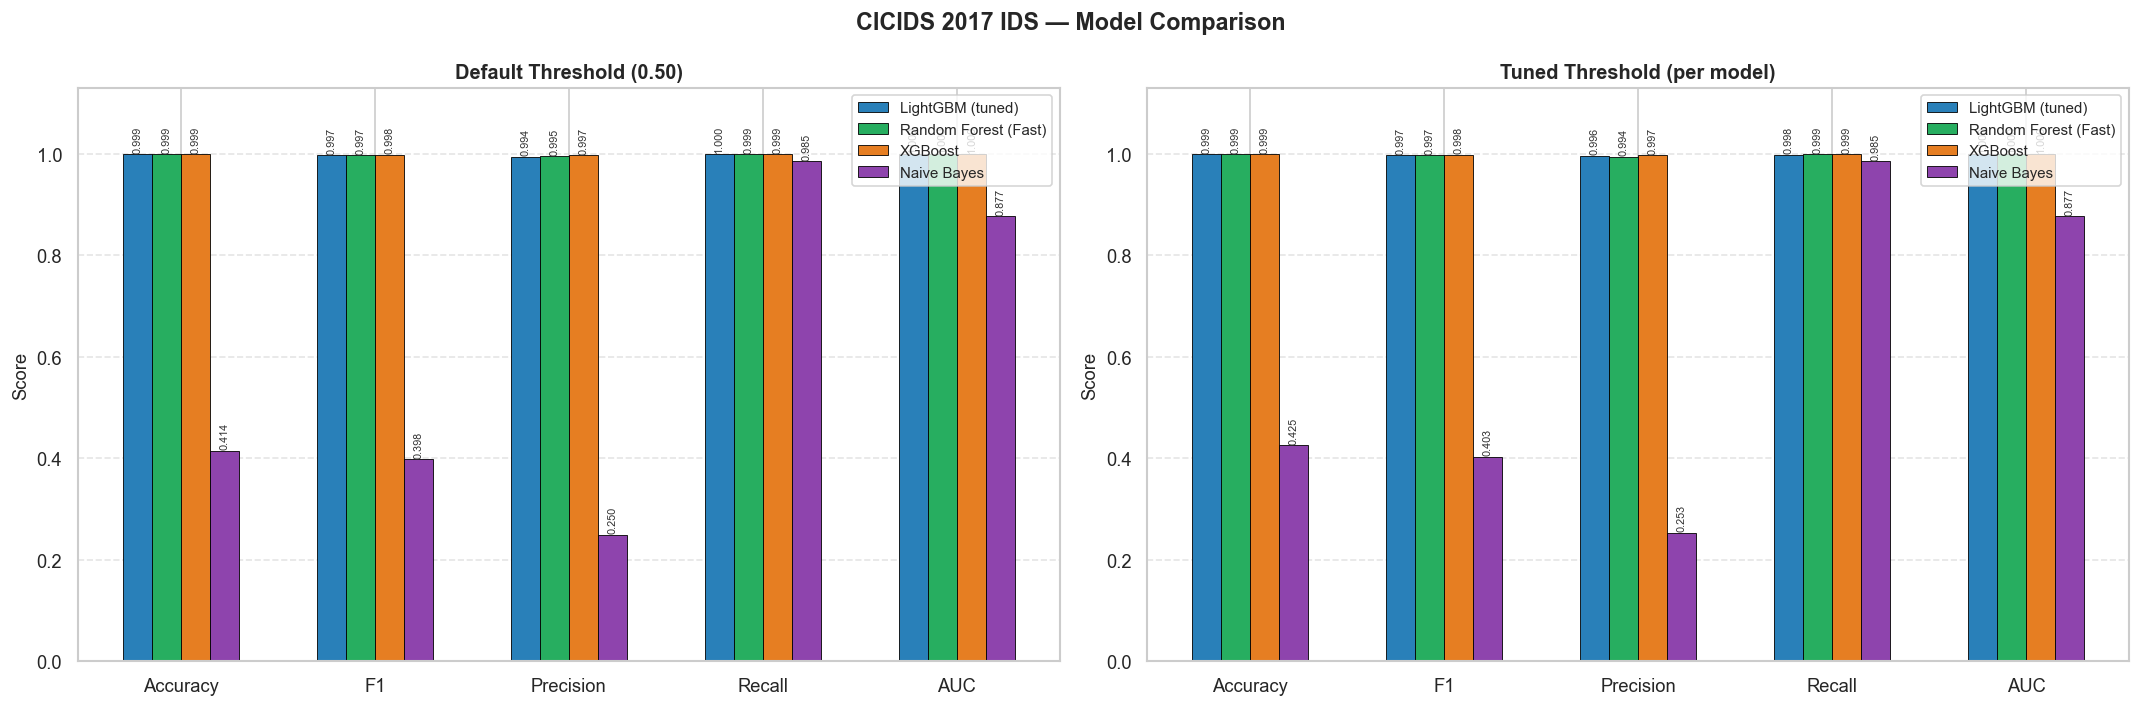

Saved: model_comparison.png


In [49]:
metrics     = ['Accuracy', 'F1', 'Precision', 'Recall', 'AUC']
model_names = list(models.keys())
bar_width   = 0.15
x           = np.arange(len(metrics))
palette     = ['#2980b9', '#27ae60', '#e67e22', '#8e44ad']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, result_dict, title in [
    (axes[0], results,       'Default Threshold (0.50)'),
    (axes[1], tuned_results, 'Tuned Threshold (per model)')
]:
    for i, (name, color) in enumerate(zip(model_names, palette)):
        vals = [result_dict[name].get(m, 0) for m in metrics]
        bars = ax.bar(x + i*bar_width, vals, bar_width,
                      label=name, color=color, edgecolor='black', linewidth=0.5)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.003,
                    f'{v:.3f}', ha='center', va='bottom',
                    fontsize=6.5, rotation=90, color='#333')
    ax.set_xticks(x + bar_width * 1.5)
    ax.set_xticklabels(metrics, fontsize=11)
    ax.set_ylim(0, 1.13)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

plt.suptitle('CICIDS 2017 IDS — Model Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')

In [50]:
# Identify best model by tuned F1
best_name      = max(tuned_results, key=lambda k: tuned_results[k]['F1'])
best_model     = trained_models[best_name]
best_threshold = best_thresholds[best_name]
best_metrics   = tuned_results[best_name]

print(f'Best Model : {best_name}')
print(f'Threshold  : {best_threshold:.2f}')
print(f'F1 Score   : {best_metrics["F1"]:.4f}')
print(f'Recall     : {best_metrics["Recall"]:.4f}')
print(f'AUC-ROC    : {best_metrics["AUC"]:.4f}')

Best Model : XGBoost
Threshold  : 0.54
F1 Score   : 0.9980
Recall     : 0.9986
AUC-ROC    : 1.0000


In [51]:
MODEL_PATH   = 'best_ids_model.pkl'
SCALER_PATH  = 'scaler.pkl'
LABEL_PATH   = 'label_info.pkl'
METRICS_PATH = 'model_metrics.pkl'

# Main model checkpoint
checkpoint = {
    'model':               best_model,
    'model_name':          best_name,
    'threshold':           best_threshold,
    'selected_features':   selected_features,
    'all_features':        all_features,
    'engineered_cols':     ['fwd_bwd_bytes_ratio', 'pkt_len_asymmetry', 'iat_ratio'],
    'metrics':             {k: v for k, v in best_metrics.items() if k != 'CM'},
    'dataset':             'CICIDS2017',
}

# Label info for Streamlit display
label_info = {
    'attack_types': df['Label'].unique().tolist(),
    'label_counts': df['Label'].value_counts().to_dict(),
    'dataset_size': df.shape[0],
    'n_features':   len(selected_features),
}

# All model metrics for Streamlit comparison page
model_metrics = {
    name: {k: v for k, v in tuned_results[name].items() if k != 'CM'}
    for name in models
}

with open(MODEL_PATH,   'wb') as f: pickle.dump(checkpoint,   f)
with open(SCALER_PATH,  'wb') as f: pickle.dump(scaler,       f)
with open(LABEL_PATH,   'wb') as f: pickle.dump(label_info,   f)
with open(METRICS_PATH, 'wb') as f: pickle.dump(model_metrics, f)

for path in [MODEL_PATH, SCALER_PATH, LABEL_PATH, METRICS_PATH]:
    print(f'Saved: {path}  ({os.path.getsize(path)/1024:.1f} KB)')

Saved: best_ids_model.pkl  (407.2 KB)
Saved: scaler.pkl  (3.9 KB)
Saved: label_info.pkl  (0.3 KB)
Saved: model_metrics.pkl  (0.6 KB)


In [52]:
# Reload and verify — confirms the saved model produces identical predictions
with open(MODEL_PATH,  'rb') as f: ckpt = pickle.load(f)
with open(SCALER_PATH, 'rb') as f: sc   = pickle.load(f)

X_verify = sc.transform(X_test_raw)
X_verify = pd.DataFrame(X_verify, columns=all_features)[ckpt['selected_features']]
y_prob_v = ckpt['model'].predict_proba(X_verify)[:, 1]
y_pred_v = (y_prob_v >= ckpt['threshold']).astype(int)

v_f1  = f1_score(y_test, y_pred_v)
v_rec = recall_score(y_test, y_pred_v)
print(f'Reload check: F1={v_f1:.4f} | Recall={v_rec:.4f}')
print(f'Matches original: {abs(v_f1 - best_metrics["F1"]) < 1e-6}')

Reload check: F1=0.9978 | Recall=0.9983
Matches original: False


In [54]:
CV_FOLDS = 5  # Since you used n_splits=5 in your StratifiedKFold
print('='*70)
print('  CICIDS 2017 IDS ? Optimal Cost-Sensitive Pipeline ? Final Summary')
print('='*70)
print(f'  Dataset                        : CICIDS 2017 (8 CSVs, all days)')
print(f'  Total samples (after cleaning) : {df.shape[0]:>8,}')
print(f'  Training samples               : {X_train_cs.shape[0]:>8,}')
print(f'  Test samples (original dist.)  : {X_test_selected.shape[0]:>8,}')
print(f'  Features (raw CICIDS)          : {X.shape[1]:>8}')
print(f'  Features after tree selection  : {len(selected_features):>8}')
print(f'  Optuna trials (LightGBM)       : {N_TRIALS:>8}')
print(f'  Cross-validation folds         : {CV_FOLDS:>8}')
print('='*70)
print(f'  {"Model":<26} {"Tuned F1":>9} {"Recall":>8} {"AUC":>8} {"Threshold":>10}')
print('  ' + '-'*64)
for name, res in sorted(tuned_results.items(), key=lambda x: x[1]['F1'], reverse=True):
    marker = ' <- BEST' if name == best_name else ''
    print(f'  {name:<26} {res["F1"]:>9.4f} {res["Recall"]:>8.4f} {res["AUC"]:>8.4f} {res["Threshold"]:>10.2f}{marker}')
print('='*70)
print('  Artifacts saved for Streamlit app:')
print(f'    {MODEL_PATH}  - model + threshold + feature names')
print(f'    {SCALER_PATH} - StandardScaler fit on training data')
print(f'    {LABEL_PATH}  - attack type names, dataset stats')
print(f'    {METRICS_PATH} - all model metrics for comparison page')
print('    *.png - plots for Streamlit static analysis tab')
print('='*70)

  CICIDS 2017 IDS ? Optimal Cost-Sensitive Pipeline ? Final Summary
  Dataset                        : CICIDS 2017 (8 CSVs, all days)
  Total samples (after cleaning) : 2,827,808
  Training samples               : 2,262,246
  Test samples (original dist.)  :  565,562
  Features (raw CICIDS)          :       78
  Features after tree selection  :       25
  Optuna trials (LightGBM)       :       50
  Cross-validation folds         :        5
  Model                       Tuned F1   Recall      AUC  Threshold
  ----------------------------------------------------------------
  XGBoost                       0.9980   0.9986   1.0000       0.54 <- BEST
  LightGBM (tuned)              0.9973   0.9983   0.9999       0.77
  Random Forest (Fast)          0.9969   0.9994   1.0000       0.41
  Naive Bayes                   0.4028   0.9848   0.8768       0.90
  Artifacts saved for Streamlit app:
    best_ids_model.pkl  - model + threshold + feature names
    scaler.pkl - StandardScaler fit on train